# Chapter 18: When an Action Has Coordinates

A release button moves after the controller observes the page. The old coordinates now point to delete. The controller can still issue a perfectly formed click, but the effect boundary has changed. The mistake is not explained by text prediction alone; it belongs to observation age, layout state, and action targeting.

This notebook represents three interfaces. Coordinate action uses the current object at an old location. Semantic action uses the resolved object identifier. Version-bound action also checks that the observed and current layouts match. All three still require freshness and current permission. The experiment distinguishes issuing an action, hitting the intended target, and confirming completion.

**Outcome:** Compare coordinate, semantic, and version-bound action contracts.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let age be observation age and tau the maximum permitted age. Freshness is F=1{age<=tau}. Current authorization is A. Target correctness is T=1{resolved target=wanted target}. Version validity is V=1{observed version=current version} for the version-bound interface.

For coordinate and semantic methods, issuance is F and A under this simplified contract. For version-bound action it is F and A and V. Authorized confirmed completion additionally requires target correctness and an effect-confirmation flag. Those predicates represent different evidence: an issued request can be wrong, and a correct target can still lack confirmation.

The coordinate method deliberately has no semantic identity check before issuance. The semantic method avoids the particular moved-location failure but can still resolve the wrong object. Version binding rejects a changed layout rather than guessing whether the old observation remains sufficient. Age and version are separate: a recent observation can already be obsolete, and an old observation may describe an unchanged layout.

## Apply this to an agent

A computer-use agent acts on an interface that can change after observation. Compare a screen location, a semantic target and a version-bound request. Keep permission, correct targeting and confirmation of the effect as separate checks.

## A calculation you can run

Supply age, freshness limit, observed and current versions, current permission, effect confirmation, and target identifiers. Exact boolean checks keep authorization and confirmation distinct from truthy strings. The function emits one row per interface with freshness, version match, authorization, issuance, target correctness, and confirmed completion.

Two figures compare issued actions and confirmed completions. Their difference is operationally important; a higher issuance bar does not imply better behavior. Run the default layout-change case, then increase only observation age beyond the limit. Predict which interfaces will refuse issuance. The transfer case removes permission while preserving fresh, matching observations, checking that a stable interface cannot manufacture authority.

For a visual version of the stale-coordinate example, open the [release console](../Companion/release-console.html) in a browser. It is a local mock-up whose effects stay inside the page.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 18
inputs = {'observation_age': 1,
 'max_age': 2,
 'observed_version': 'layout-1',
 'current_version': 'layout-2',
 'current_permission': True,
 'effect_confirmed': True,
 'coordinate_target': 'delete',
 'semantic_target': 'release',
 'wanted_target': 'release',
 'change_rate': 0.02,
 'delays': [5, 15, 30]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: constructed teaching example

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": true,
      "version_matches": true,
      "authorized": true,
      "issued": true,
      "correct_target": false,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": true,
      "version_matches": true,
      "authorized": true,
      "issued": true,
      "correct_target": true,
      "confirmed_completion": true
    },
    {
      "method": "version-bound",
      "fresh": true,
      "version_matches": false,
      "authorized": true,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": false,
  "layout_changed": true,
  "change_rate": 0.02,
  "freshness_probability_at_age": 0.9801986733,
  "freshness_probability_at_max_age": 0.9

The default coordinate action is issued at a fresh observation age but points to delete, so confirmed completion is false. Semantic targeting points to release and is issued, giving confirmed completion true under the supplied receipt flag. Version-bound action refuses issuance because layout-1 differs from layout-2.

In the changed case age 3 exceeds max_age 2. All interfaces refuse issuance, including the semantic one. Freshness policy changes the action set before any claim of completion. The result does not say the page was unusable; it says this declared contract requires a renewed observation before acting.

Equation 18.3 is also computed when change_rate is supplied. With rate 0.02 changes per second, delays of 5, 15 and 30 seconds give freshness probabilities 0.9048, 0.7408 and 0.5488, which reproduces the chapter's second exercise. This is a constant-rate model of how likely no invalidating change has occurred. It is reported beside the age-limit rule, not in place of it, and a bursty update pattern would make it unsuitable.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


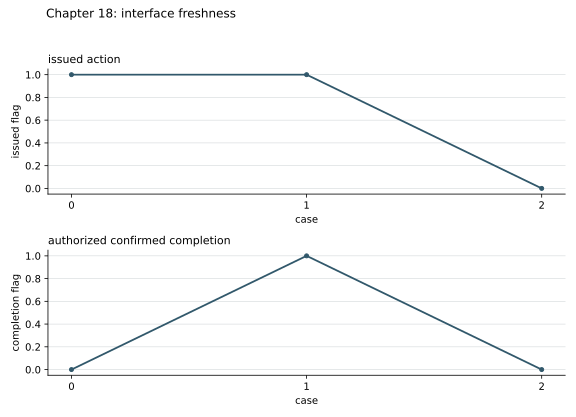

In [3]:
display(SVG(figure_svg(report)))

**Figure 18.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Semantic targeting is not a universal repair for computer-use errors. Labels can be duplicated, accessibility trees can be stale, and resolver rules can name the wrong object. The runtime accepts a declared semantic target so that this boundary stays visible rather than assuming semantics equals correctness.

A second failure treats historical permission as current authority. The controller must check permission at issuance, not merely remember that a similar action was allowed earlier. The transfer case blocks every method despite correct targets and matching versions.

Finally, a click receipt is not necessarily an effect receipt. This experiment's confirmation flag refers to the desired completed effect. Real interfaces may need a state query, durable operation identifier, or verification page. Do not translate a low-level input event into terminal completion without that evidence.

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": false,
      "version_matches": true,
      "authorized": true,
      "issued": false,
      "correct_target": false,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": false,
      "version_matches": true,
      "authorized": true,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "version-bound",
      "fresh": false,
      "version_matches": false,
      "authorized": true,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": true,
  "layout_changed": true,
  "change_rate": 0.02,
  "freshness_probability_at_age": 0.9417645336,
  "freshness_probability_a

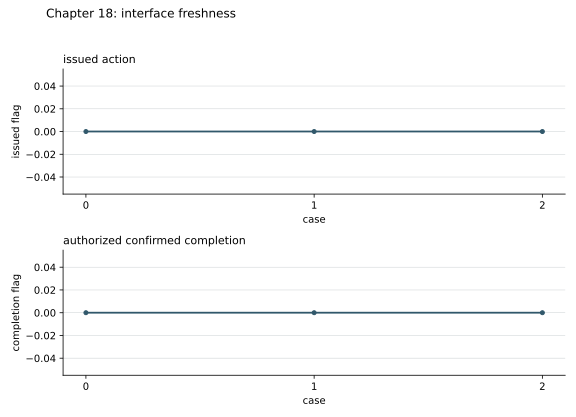

In [4]:
changed_inputs = {'observation_age': 3,
 'max_age': 2,
 'observed_version': 'layout-1',
 'current_version': 'layout-2',
 'current_permission': True,
 'effect_confirmed': True,
 'coordinate_target': 'delete',
 'semantic_target': 'release',
 'wanted_target': 'release',
 'change_rate': 0.02,
 'delays': [5, 15, 30]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 18.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer observation is fresh, versions match, and both target methods resolve submit correctly. Current permission is false, so every issuance flag is false. This is an authority boundary independent of perception accuracy.

To apply this to your own system, preserve the observed target, action-time target, layout version, and timestamp. If a field is unavailable, specify the observation needed instead of guessing it. Compare interfaces under the same task and permission contract. Use uncertain-effect tracing after issuance when the real question is whether the remote action happened despite a missing acknowledgement.

In [5]:
transfer_inputs = {'observation_age': 0,
 'max_age': 1,
 'observed_version': 'page-C',
 'current_version': 'page-C',
 'current_permission': False,
 'effect_confirmed': False,
 'coordinate_target': 'submit',
 'semantic_target': 'submit',
 'wanted_target': 'submit',
 'change_rate': 0.05,
 'delays': [2, 10]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: constructed transfer example

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "version-bound",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": false,
  "layout_changed": false,
  "change_rate": 0.05,
  "freshness_probability_at_age": 1.0,
  "freshness_probability_at_max_age": 0.95122

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **observation_age:** Nonnegative elapsed time since observation.
- **max_age:** Nonnegative freshness limit in the same time unit.
- **observed_version:** Version seen in the observation.
- **current_version:** Version at action time.
- **current_permission:** Exact boolean current authorization.
- **effect_confirmed:** Exact boolean receipt of desired effect confirmation.
- **coordinate_target:** Current object located at previously observed coordinates.
- **semantic_target:** Current object resolved by semantic interface.
- **wanted_target:** Intended object identifier.
- **change_rate:** Optional nonnegative rate of invalidating interface changes per unit time. When given, Fresh(delay)=exp(-rate*delay) from Equation 18.3 is reported.
- **delays:** Optional list of nonnegative delays in the same time unit; requires change_rate.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch18.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "version-bound",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": false,
  "layout_changed": false,
  "change_rate": 0.05,
  "freshness_probability_at_age": 1.0,
  "freshness_

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c18-d01"></a>

### Demonstration 1: One command, two layouts, three interfaces

If the controller is unsure which layout is current, what does each kind of command do, and what does a permission check change?

![Equation 18.1](../assets/math/755fe6a5928a4b2e29ce.svg)

**Symbols and units:** x is the current state (here, which layout is on screen), a is the proposed command, and a-tilde is the operation the interface actually realizes: release v2, release v3 or a denial. Exec(a-tilde | x, a) is the chance the interface realizes a-tilde, and P(x' | x, a-tilde) is the world's law for the next state x'. Act with subscript ui is the set of operations the interface can realize, and Exec with subscript ui is the interface's own chance of realizing one. The belief is the controller's probability that layout 1 is current. A coordinate command is a position; a semantic command names a control bound to v2; a transactional command names v2 and the saved screen version, which the service checks at commit.

In layout 1 the saved click realizes release v2 for certain; in layout 2 the coordinate realizes release v3 for certain, or a denial if the permission check is on. Equation (18.1) multiplies each realized operation by its world effect and adds, and the belief averages over the two layouts. Uncertainty sits in which layout is current, not in the click. The semantic request is bound to the object, so the swap does not move it, and the transactional request adds the saved version, so a changed layout produces a refusal instead of an effect on a new record.

**Use in this chapter:** Before trusting a command, write down what it realizes under every layout you consider possible, and which of those realizations a current check would block. Compare interfaces with the task, the document, the authority and the deadline held fixed.

**Assumptions:** Two layouts, each with a deterministic realized operation that leads to one next state, and complete mediation when the check is on. The beliefs are probabilities in a constructed model, not measured accuracies of any visual model. The semantic request is taken to resolve v2 correctly; a mislabeled or ambiguous control would break that, and a transactional request can fail because its precondition expired even when a person would accept the newer version. If an unmediated route to the service exists, the check does not apply.

**Predict before running:** With belief 0.6 in layout 1, no permission check and the coordinate command, what is the chance of a prohibited release?

**Controls you can change:**

- **Kind of command:** `interface` accepts 'coordinate', 'semantic', 'transactional'.
- **Belief that layout 1 (v2 on top) is current:** `belief_layout1` accepts 0.6, 0.8.
- **Current permission check at the service:** `permission_check` accepts 'off', 'on'.

**Source section:** The interface belongs in the transition law.

**Evidence:** constructed teaching example.

Constructed example: the chapter's two-layout console with its 0.8 and 0.2 beliefs and chapter exercise 1's 0.6 and 0.4; the three interfaces are the chapter's, with issuance and target correctness computed by the laboratory's interface calculation.

Prediction choices:

1. 0.60
2. 0.40
3. 0.00

**Common wrong turn:** The chapter notes that the improvement from a permission check comes from enforcement: the controller has not become better at locating the button. A better visual model might reduce misreading, but it cannot establish that a previously observed interface has remained unchanged. Turn the check on: the belief is the same, the prohibited release disappears.

One command, two layouts, three interfaces
Controls: {"interface": "coordinate", "belief_layout1": 0.8, "permission_check": "off"}
Evidence: constructed teaching example

Calculated quantities:
Release v2 (authorized completion): 0.80
Release v3 (prohibited release): 0.20
Denied or refused, no release: 0.00
Total: 1.00

Worked steps:
1. Layout 1: the coordinate command realizes release v2; layout 2: release v3.
2. P(release v2) = 0.80 x 1 + 0.20 x 0 = 0.80.
3. P(release v3) = 0.80 x 0 + 0.20 x 1 = 0.20.
4. P(no release) = 0.80 x 0 + 0.20 x 0 = 0.00.
5. Check: 0.80 + 0.20 + 0.00 = 1.00.

Layout 1 (v2 on top) has belief 0.80; layout 2 (rows swapped) has 0.20. The coordinate command takes its target from whatever occupies the saved point when it arrives. P(release v2) = 0.80 x 1 + 0.20 x 0 = 0.80. P(release v3) = 0.80 x 0 + 0.20 x 1 = 0.20. P(no release) = 0.80 x 0 + 0.20 x 0 = 0.00. The three add to 1.00, as a normalized transition law must. With no check, the wrong-layout branch becomes

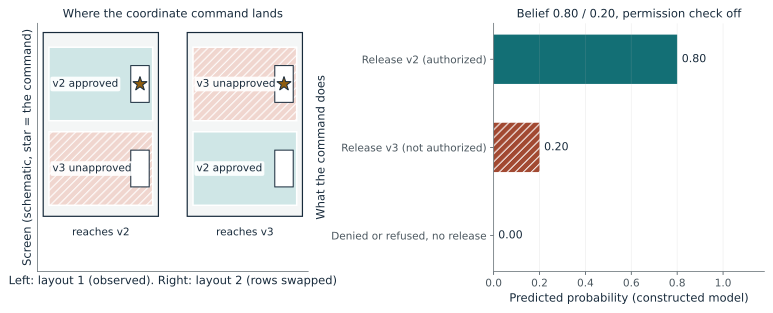

In [8]:
demo_id = 'C18-D01'
demo_controls = {'interface': 'coordinate', 'belief_layout1': 0.8, 'permission_check': 'off'}
demo_result = run_demo(18, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Kind of command** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

One command, two layouts, three interfaces
Controls: {"interface": "semantic", "belief_layout1": 0.8, "permission_check": "off"}
Evidence: constructed teaching example

Calculated quantities:
Release v2 (authorized completion): 1.00
Release v3 (prohibited release): 0.00
Denied or refused, no release: 0.00
Total: 1.00

Worked steps:
1. Layout 1: the semantic command realizes release v2; layout 2: release v2.
2. P(release v2) = 0.80 x 1 + 0.20 x 1 = 1.00.
3. P(release v3) = 0.80 x 0 + 0.20 x 0 = 0.00.
4. P(no release) = 0.80 x 0 + 0.20 x 0 = 0.00.
5. Check: 1.00 + 0.00 + 0.00 = 1.00.

Layout 1 (v2 on top) has belief 0.80; layout 2 (rows swapped) has 0.20. The semantic request names the control bound to v2, so swapping the rows does not move its target (here the identifier is taken to resolve correctly; a mislabeled control would break that). P(release v2) = 0.80 x 1 + 0.20 x 1 = 1.00. P(release v3) = 0.80 x 0 + 0.20 x 0 = 0.00. P(no release) = 0.80 x 0 + 0.20 x 0 = 0.00. The three add to

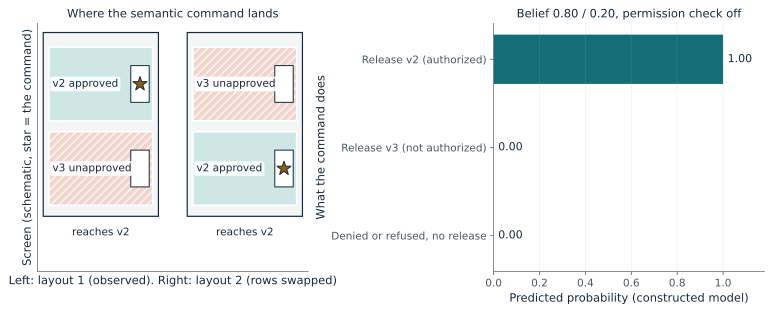

In [9]:
changed_controls = {'interface': 'semantic', 'belief_layout1': 0.8, 'permission_check': 'off'}
changed_demo = run_demo(18, 'C18-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(18, 'C18-D01'):
    state = run_demo(18, 'C18-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "interface": "coordinate",
      "belief_layout1": 0.6,
      "permission_check": "off"
    },
    "metrics": [
      [
        "Release v2 (authorized completion)",
        "0.60"
      ],
      [
        "Release v3 (prohibited release)",
        "0.40"
      ],
      [
        "Denied or refused, no release",
        "0.00"
      ],
      [
        "Total",
        "1.00"
      ]
    ]
  },
  {
    "controls": {
      "interface": "coordinate",
      "belief_layout1": 0.6,
      "permission_check": "on"
    },
    "metrics": [
      [
        "Release v2 (authorized completion)",
        "0.60"
      ],
      [
        "Release v3 (prohibited release)",
        "0.00"
      ],
      [
        "Denied or refused, no release",
        "0.40"
      ],
      [
        "Total",
        "1.00"
      ]
    ]
  },
  {
    "controls": {
      "interface": "coordinate",
      "belief_layout1": 0.8,
      "permission_check": "off"
    },
    "metrics": [
      [
 

**Check your understanding:** With belief 0.7 in layout 1, what is the chance of a prohibited release for the coordinate command with no check, and with the check on?

[Answer and worked reasoning](../solutions/ch18.md#demonstration-1). [Matching browser demonstration](../readers/18-interface-freshness/reader.html#C18-D01).

<a id="demo-c18-d02"></a>

### Demonstration 2: What survives when the screen is uncertain

Which commands stay authorized in every layout the controller still considers possible, which state removes the rest, and which observation restores them?

![Equation 18.2](../assets/math/4b0b524edbcf02f6262f.svg)

**Symbols and units:** b(x) is the belief weight of state x, here layout 1 or layout 2. The set written A with subscript auth, at x, holds the commands whose protected effect is authorized in state x. The set written A with subscript rob, at b, is the intersection of those sets over every state with positive belief. A perfect read is an observation that shows which layout is current.

A command is kept only if every state with positive weight authorizes it. Layout 2 does not authorize the saved-point click, so any positive weight on layout 2 removes it, while zero weight leaves layout 2 out of the intersection entirely. The weight itself never enters the result, only whether it is positive. The last column names the state that removed each command, and a perfect read narrows the support: seeing layout 1 restores the click, seeing layout 2 confirms its removal.

**Use in this chapter:** When a decision is removed by a state you think unlikely, the record shows which state removed it and which observation (a fresh screenshot, a metadata read) could narrow the support and restore it. Reading can often be permitted over a broader set of states than releasing, which is why it stays available.

**Assumptions:** The true layout must lie inside the counted support, and the authorization sets must be specified correctly; if either fails, the intersection guarantees nothing. The sets here are constructed, and the construction is conservative: it is not a substitute for the service's own current permission check. A read only helps if it is current and correct.

**Predict before running:** Layout 2 has belief only 0.01 and nothing further is observed. Does the saved-point click survive the intersection?

**Controls you can change:**

- **Belief that layout 2 (rows swapped) is current:** `belief_layout2` accepts 0.0, 0.01, 0.5, 1.0.
- **Further observation:** `observation` accepts 'none', 'layout1', 'layout2'.

**Source section:** A belief over screens.

**Evidence:** constructed teaching example.

Constructed example: the chapter's two-layout case, with authorization sets defined for this reader and belief weights chosen for illustration.

Prediction choices:

1. Yes, 0.01 is negligible
2. No, any positive weight removes it

**Common wrong turn:** The chapter says a high-probability intended target is not current authority for a different target. At belief 0.99 in layout 1 the click is probably right, yet the 0.01 on layout 2 removes it, because the intersection asks what is authorized throughout the support, not what is most likely.

What survives when the screen is uncertain
Controls: {"belief_layout2": 0.01, "observation": "none"}
Evidence: constructed teaching example

Calculated quantities:
Belief in layout 1: 0.99
Belief in layout 2: 0.01
Layouts counted: layout 1 and layout 2
Commands kept: 4 of 5
Saved-point click: removed

Worked steps:
1. Beliefs: layout 1 = 0.99, layout 2 = 0.01; they add to 1.00.
2. States with positive belief: layout 1 and layout 2.
3. Each command must be authorized in every counted layout; the saved-point click is not authorized in layout 2.
4. Commands removed = 5 - 4 = 1; the saved-point click is removed.

Beliefs add to 0.99 + 0.01 = 1.00. Both beliefs are above zero, so both layouts count, whatever their size. The click reaches an unapproved record in layout 2, so it is not authorized throughout the support. Commands removed = 5 - 4 = 1, so the saved-point click is removed and 4 of 5 commands remain. The request for v2 survives in either layout only because the service checks iden

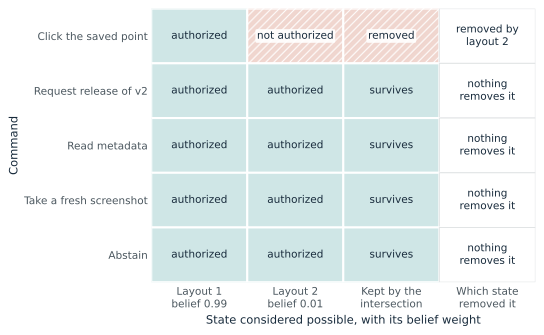

In [11]:
demo_id = 'C18-D02'
demo_controls = {'belief_layout2': 0.01, 'observation': 'none'}
demo_result = run_demo(18, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Belief that layout 2 (rows swapped) is current** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

What survives when the screen is uncertain
Controls: {"belief_layout2": 0.0, "observation": "none"}
Evidence: constructed teaching example

Calculated quantities:
Belief in layout 1: 1.00
Belief in layout 2: 0.00
Layouts counted: layout 1
Commands kept: 5 of 5
Saved-point click: kept

Worked steps:
1. Beliefs: layout 1 = 1.00, layout 2 = 0.00; they add to 1.00.
2. States with positive belief: layout 1.
3. Each command must be authorized in every counted layout; the saved-point click is not authorized in layout 2.
4. Commands removed = 5 - 5 = 0; the saved-point click survives.

Beliefs add to 1.00 + 0.00 = 1.00. Layout 2 has zero belief and is left out of the intersection, so only layout 1 constrains the set. That is safe only if the true layout really is layout 1. Commands removed = 5 - 5 = 0, so the saved-point click survives and 5 of 5 commands remain. The request for v2 survives in either layout only because the service checks identity and approval at commit; belief alone never aut

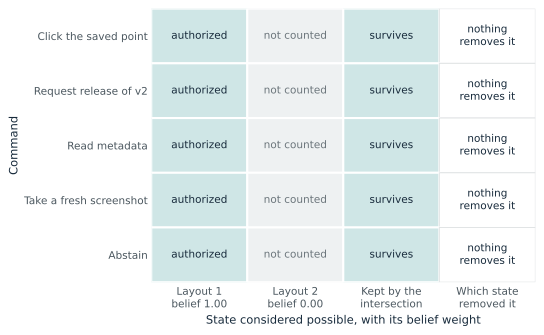

In [12]:
changed_controls = {'belief_layout2': 0.0, 'observation': 'none'}
changed_demo = run_demo(18, 'C18-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(18, 'C18-D02'):
    state = run_demo(18, 'C18-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "belief_layout2": 0.0,
      "observation": "none"
    },
    "metrics": [
      [
        "Belief in layout 1",
        "1.00"
      ],
      [
        "Belief in layout 2",
        "0.00"
      ],
      [
        "Layouts counted",
        "layout 1"
      ],
      [
        "Commands kept",
        "5 of 5"
      ],
      [
        "Saved-point click",
        "kept"
      ]
    ]
  },
  {
    "controls": {
      "belief_layout2": 0.0,
      "observation": "layout1"
    },
    "metrics": [
      [
        "Belief in layout 1",
        "1.00"
      ],
      [
        "Belief in layout 2",
        "0.00"
      ],
      [
        "Layouts counted",
        "layout 1"
      ],
      [
        "Commands kept",
        "5 of 5"
      ],
      [
        "Saved-point click",
        "kept"
      ]
    ]
  },
  {
    "controls": {
      "belief_layout2": 0.0,
      "observation": "layout2"
    },
    "metrics": [
      [
        "Belief in layout 1",
        "0.

**Check your understanding:** If layout 2 has belief 0.001 and nothing further is observed, does the saved-point click survive? What if the belief is exactly 0?

[Answer and worked reasoning](../solutions/ch18.md#demonstration-2). [Matching browser demonstration](../readers/18-interface-freshness/reader.html#C18-D02).

<a id="demo-c18-d03"></a>

### Demonstration 3: How long a picture stays useful

Given its age, its saved version and the current permission, which interface may act, and how fast does a coordinate go stale if changes arrive at a steady rate?

![Equation 18.3](../assets/math/2f33e21b021d2dab73fc.svg)

**Symbols and units:** Delta is the delay between observing and acting, in seconds. Lambda with subscript ui is the rate of invalidating interface changes, in changes per second. Their product is a pure number. Fresh(Delta) is the chance that no invalidating change occurred during the delay. Separately, the age rule compares the observation's age with a limit; the version-bound interface also compares the saved version with the current one; every interface needs current permission.

If changes arrive at a constant rate, the chance of none in a delay falls as an exponential of rate times delay. Doubling the delay squares the freshness: at 0.02 per second, 15 seconds gives 0.7408 and 30 seconds gives 0.5488, which is 0.7408 squared. The table shows what the age rule, the version and the permission do on top of that: in the default case the age is within its limit but the layout changed, so only the version-bound request refuses; in the changed case the age passes its limit and all three refuse; in the transfer case permission is false and every interface refuses although the observation is fresh and the versions match.

**Use in this chapter:** Choose a maximum observation age by deciding what chance of an invalidating change you will accept, then refresh the observation or bind the command to a state version before that age is reached, and check current permission at issuance, not from memory.

**Assumptions:** The table and the curve are independent: the table uses the case's observation age, the curve uses the chosen delay. In the default and changed cases the coordinate target is called delete, the notebook's name for the wrong object (v3 in Demonstration 1). Constant-rate, memoryless changes, and a clear definition of which changes invalidate the binding. Real interfaces can update periodically, in bursts, or in response to the agent's own actions, and a rate taken from quiet periods can mislead. The rates and limits here are teaching inputs. Semantic resolution can itself be wrong, and a click receipt is not an effect receipt.

**Predict before running:** At 0.02 changes per second, is the chance of still being fresh after 30 seconds above or below one half?

**Controls you can change:**

- **Case:** `scenario` accepts 'default', 'changed', 'transfer'.
- **Delay before acting (seconds):** `delay` accepts 5, 10, 15, 30.

**Source section:** How long a picture stays useful.

**Evidence:** constructed teaching example.

Constructed example: the notebook's default case (age 1 against a limit of 2, layout-1 against layout-2, rate 0.02), changed case (age 3) and transfer case (permission false, rate 0.05), computed with the laboratory's interface function, and the chapter's delays of 5 and 30 seconds with chapter exercise 2's 15; the delay of 10 seconds is defined for this reader.

Prediction choices:

1. Above one half
2. Below one half

**Common wrong turn:** The chapter notes that a fresh observation has latency: if observation, interpretation and execution take several seconds, a controller can keep acquiring a new image and still act on an old state. Age by itself does not decide validity; a state version, a lock, a commit precondition or a service action that checks the object may be needed.

How long a picture stays useful
Controls: {"scenario": "default", "delay": 30}
Evidence: constructed teaching example

Calculated quantities:
Rate: 0.02 per second
Delay: 30 seconds
Rate x delay: 0.60
Chance still fresh: 0.5488
Chance of an invalidating change: 0.4512
Delay at which freshness is one half: 34.7 seconds
Observation age against the limit: 1 s against 2 s: fresh
Interfaces that issue: coordinate, semantic
Confirmed completions: semantic

Worked steps:
1. Rate x delay = 0.02 x 30 = 0.60.
2. Fresh = exp(-0.60) = 0.5488; an invalidating change has chance 1 - 0.5488 = 0.4512.
3. Age rule: observation age 1 s against a limit of 2 s is fresh.
4. Version: saved layout-1, current layout-2; only the version-bound request compares them.
5. Current permission is true; issued = fresh and allowed (and, for version-bound, same version).
6. Issued: coordinate, semantic. Confirmed completion: semantic.

Rate x delay = 0.02 x 30 = 0.60, a pure number with no unit left. Fresh = exp(-0.60) =

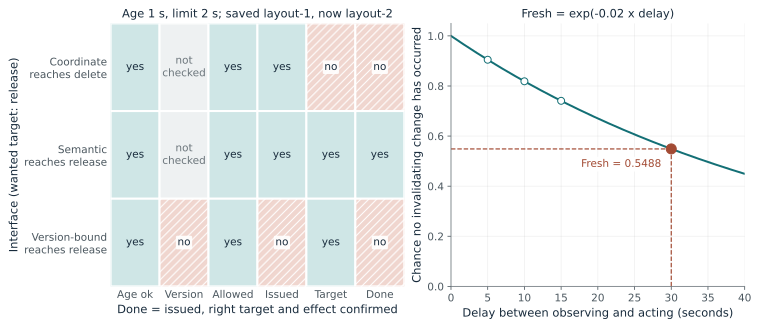

In [14]:
demo_id = 'C18-D03'
demo_controls = {'scenario': 'default', 'delay': 30}
demo_result = run_demo(18, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

How long a picture stays useful
Controls: {"scenario": "changed", "delay": 30}
Evidence: constructed teaching example

Calculated quantities:
Rate: 0.02 per second
Delay: 30 seconds
Rate x delay: 0.60
Chance still fresh: 0.5488
Chance of an invalidating change: 0.4512
Delay at which freshness is one half: 34.7 seconds
Observation age against the limit: 3 s against 2 s: stale
Interfaces that issue: none
Confirmed completions: none

Worked steps:
1. Rate x delay = 0.02 x 30 = 0.60.
2. Fresh = exp(-0.60) = 0.5488; an invalidating change has chance 1 - 0.5488 = 0.4512.
3. Age rule: observation age 3 s against a limit of 2 s is stale.
4. Version: saved layout-1, current layout-2; only the version-bound request compares them.
5. Current permission is true; issued = fresh and allowed (and, for version-bound, same version).
6. Issued: none. Confirmed completion: none.

Rate x delay = 0.02 x 30 = 0.60, a pure number with no unit left. Fresh = exp(-0.60) = 0.5488, so the chance of at least one i

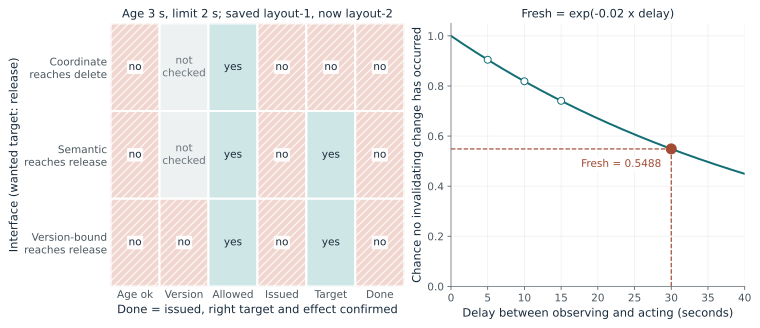

In [15]:
changed_controls = {'scenario': 'changed', 'delay': 30}
changed_demo = run_demo(18, 'C18-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(18, 'C18-D03'):
    state = run_demo(18, 'C18-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "scenario": "default",
      "delay": 5
    },
    "metrics": [
      [
        "Rate",
        "0.02 per second"
      ],
      [
        "Delay",
        "5 seconds"
      ],
      [
        "Rate x delay",
        "0.10"
      ],
      [
        "Chance still fresh",
        "0.9048"
      ],
      [
        "Chance of an invalidating change",
        "0.0952"
      ],
      [
        "Delay at which freshness is one half",
        "34.7 seconds"
      ],
      [
        "Observation age against the limit",
        "1 s against 2 s: fresh"
      ],
      [
        "Interfaces that issue",
        "coordinate, semantic"
      ],
      [
        "Confirmed completions",
        "semantic"
      ]
    ]
  },
  {
    "controls": {
      "scenario": "default",
      "delay": 10
    },
    "metrics": [
      [
        "Rate",
        "0.02 per second"
      ],
      [
        "Delay",
        "10 seconds"
      ],
      [
        "Rate x delay",
        "0.20

**Check your understanding:** At 0.05 invalidating changes per second and a 20 second delay, what is Fresh?

[Answer and worked reasoning](../solutions/ch18.md#demonstration-3). [Matching browser demonstration](../readers/18-interface-freshness/reader.html#C18-D03).

<a id="demo-c18-d04"></a>

### Demonstration 4: The price of another look

When does one more observation before the click earn its cost?

![Equation 18.1](../assets/math/755fe6a5928a4b2e29ce.svg)

**Symbols and units:** The chance the saved point is wrong is the probability of the layout in which the click reaches the wrong record. The loss is what that outcome costs, in declared utility units. A second observation costs 1 or 2 units and is assumed to settle which layout is current. Equation (18.1) describes the possible outcomes of the click (its symbols are defined in Demonstration 1: a-tilde is a realized operation, Exec with subscript ui its chance, Act with subscript ui the set of realizable operations, x' the next state). This demonstration's own comparison is: expected loss of clicking now = chance x loss, and looking pays when chance x loss is more than its cost.

Clicking now costs the chance of a wrong target times its loss. Looking first costs its price and removes that loss. The look pays when chance x loss exceeds the price, which gives a break-even chance of the price divided by the loss. Enforcement matters because it changes the loss, not the chance; binding the command to v2 with a version check removes the chance for document identity altogether, leaving the look nothing to buy on that question.

**Use in this chapter:** Do not buy information because uncertainty exists. Price the wrong-target branch under the interface you actually have, and look again only when that expected loss is larger than the cost of looking.

**Assumptions:** The look is perfect, execution follows at once, and the loss lumps delay, retries and side effects into one number. A denied attempt can also use up a rate limit, lock an account or reveal information; if so the loss of 3 is too small. A deadline can raise the cost of looking. The number 2 is not a general price for visual safety.

**Predict before running:** With a wrong-target loss of 3 (a denial) instead of 40, a look costing 2 and a 0.1 chance of being wrong, does the extra look still pay?

**Controls you can change:**

- **Loss if the click reaches the wrong record:** `wrong_loss` accepts 40, 3.
- **Chance the saved point is wrong:** `wrong_chance` accepts 0.0, 0.1, 0.2.
- **Cost of one more look:** `look_cost` accepts 1, 2.

**Source section:** The price of another look.

**Evidence:** constructed teaching example.

Constructed example: the chapter's 0.1 chance of a wrong target, loss of 40 or 3 and observation cost of 2, chapter exercise 3's look costing 1 with a 0.2 chance, and the chapter's third interface with chance 0.

Prediction choices:

1. Yes, it still pays
2. No, clicking now is cheaper

**Boundary of the conclusion:** Physical agents extend the problem further: contact, inertia, uncertain actuators and irreversible material effects can require additional state and control models, and this chapter establishes no transfer guarantee from desktop completion to robotics. For the release controller, the useful result is narrower: the model may choose the right intention, and the interface must still connect that intention to the right object, current permission and confirmed consequence.

**Common wrong turn:** The chapter says a controller should not buy information merely because uncertainty exists, but when the information can change an authorized decision enough to justify its cost. With complete permission mediation a wrong click only costs a denial, and the same perfect look no longer pays.

The price of another look
Controls: {"wrong_loss": 40, "wrong_chance": 0.1, "look_cost": 2}
Evidence: constructed teaching example

Calculated quantities:
Expected loss of clicking now: 4.00
Cost of one more look: 2.00
Net advantage of looking: 2.00
Break-even chance of a wrong target: 0.050
Better option: Observe first

Worked steps:
1. Expected loss of clicking now: 0.10 x 40 = 4.00.
2. A perfect look costs 2.0 and removes that loss.
3. Net advantage of looking: 4.00 - 2.0 = 2.00.
4. Break-even chance: 2.0 / 40 = 0.050; the chosen chance is 0.10.
5. Better option: observe first.

Expected loss of clicking now = 0.10 x 40 = 4.00. Looking first costs 2.0 and removes that loss, so its net advantage is 4.00 - 2.0 = 2.00. Break-even chance = 2.0 / 40 = 0.050. Observing first removes an expected loss of 4.00 for a cost of 2.0, so it pays.

Assumptions: The look is perfect, execution follows at once, and the loss lumps delay, retries and side effects into one number. A denied attempt can al

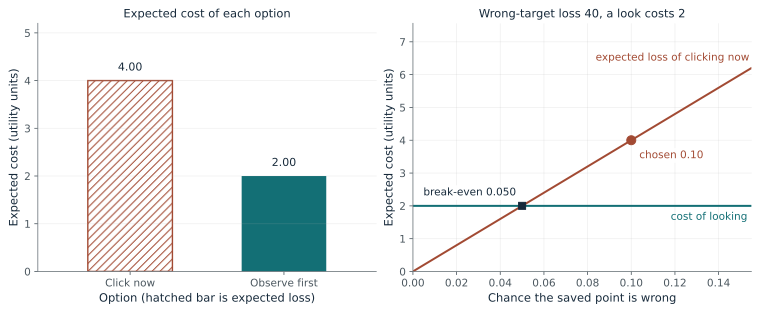

In [17]:
demo_id = 'C18-D04'
demo_controls = {'wrong_loss': 40, 'wrong_chance': 0.1, 'look_cost': 2}
demo_result = run_demo(18, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Loss if the click reaches the wrong record** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The price of another look
Controls: {"wrong_loss": 3, "wrong_chance": 0.1, "look_cost": 2}
Evidence: constructed teaching example

Calculated quantities:
Expected loss of clicking now: 0.30
Cost of one more look: 2.00
Net advantage of looking: -1.70
Break-even chance of a wrong target: 0.667
Better option: Click now

Worked steps:
1. Expected loss of clicking now: 0.10 x 3 = 0.30.
2. A perfect look costs 2.0 and removes that loss.
3. Net advantage of looking: 0.30 - 2.0 = -1.70.
4. Break-even chance: 2.0 / 3 = 0.667; the chosen chance is 0.10.
5. Better option: click now.

Expected loss of clicking now = 0.10 x 3 = 0.30. Looking first costs 2.0 and removes that loss, so its net advantage is 0.30 - 2.0 = -1.70. Break-even chance = 2.0 / 3 = 0.667. Clicking now risks an expected loss of only 0.30, below the 2.0 cost of looking, so another look does not pay.

Assumptions: The look is perfect, execution follows at once, and the loss lumps delay, retries and side effects into one number. A 

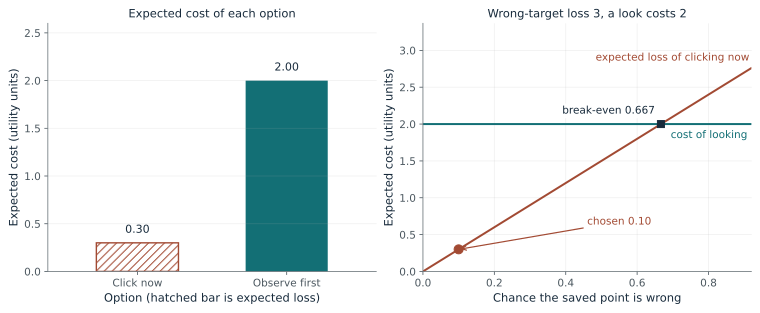

In [18]:
changed_controls = {'wrong_loss': 3, 'wrong_chance': 0.1, 'look_cost': 2}
changed_demo = run_demo(18, 'C18-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(18, 'C18-D04'):
    state = run_demo(18, 'C18-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "wrong_loss": 40,
      "wrong_chance": 0.0,
      "look_cost": 1
    },
    "metrics": [
      [
        "Expected loss of clicking now",
        "0.00"
      ],
      [
        "Cost of one more look",
        "1.00"
      ],
      [
        "Net advantage of looking",
        "-1.00"
      ],
      [
        "Break-even chance of a wrong target",
        "0.025"
      ],
      [
        "Better option",
        "Click now"
      ]
    ]
  },
  {
    "controls": {
      "wrong_loss": 40,
      "wrong_chance": 0.0,
      "look_cost": 2
    },
    "metrics": [
      [
        "Expected loss of clicking now",
        "0.00"
      ],
      [
        "Cost of one more look",
        "2.00"
      ],
      [
        "Net advantage of looking",
        "-2.00"
      ],
      [
        "Break-even chance of a wrong target",
        "0.050"
      ],
      [
        "Better option",
        "Click now"
      ]
    ]
  },
  {
    "controls": {
      "wrong_loss": 40

**Check your understanding:** If one more look cost 3 units, the wrong-target loss were 40 and the chance of a wrong target 0.1, would looking first pay?

[Answer and worked reasoning](../solutions/ch18.md#demonstration-4). [Matching browser demonstration](../readers/18-interface-freshness/reader.html#C18-D04).

## Questions

1. Why does default coordinate completion fail?

2. Can matching versions replace current permission?

3. What does observation age 3 do under max_age = 2?

4. With change_rate 0.02 per second, compute the no-invalidating-change probability for delays of 5, 15 and 30 seconds.

Answers: [separate solutions](../solutions/ch18.md). Try the calculation before opening them.

## Summary

Actions with coordinates depend on a changing interface. Freshness, version binding, current permission, target correctness, and effect confirmation are separate predicates. The moved-layout example exposes a coordinate failure; the stale-observation case blocks issuance; the transfer case blocks action for missing authority. Semantic targeting helps only within its resolver contract. The calculation reports declared interface behavior without claiming that any live page was observed or controlled.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-18-interface-freshness`](../skills/maa-18-interface-freshness/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 18.1

![Equation 18.1](../assets/math/755fe6a5928a4b2e29ce.svg)

Equation (18.1) composes an interface's execution law with the world transitions caused by its realized operations.

For each operation the command might realize in the current state, multiply its execution probability by its next-state law, then add those possibilities.

LaTeX source, preserved for inspection:

```latex
P_{\mathrm{ui}}(x'\mid x,a)
=
\sum_{\tilde a\in\operatorname{Act}_{\mathrm{ui}}}
\operatorname{Exec}_{\mathrm{ui}}(\tilde a\mid x,a)
P(x'\mid x,\tilde a).
\tag{18.1}
```

### Equation 18.2

![Equation 18.2](../assets/math/4b0b524edbcf02f6262f.svg)

Equation (18.2) retains actions authorized in every state still considered possible.

An action survives only if each state with positive belief weight permits it.

LaTeX source, preserved for inspection:

```latex
\mathcal A_{\mathrm{rob}}(\mathbf b)
=
\bigcap_{x:\,\mathbf b(x)>0}\mathcal A_{\mathrm{auth}}(x).
\tag{18.2}
```

### Equation 18.3

![Equation 18.3](../assets/math/2f33e21b021d2dab73fc.svg)

Equation (18.3) gives the chance that a coordinate binding remains valid over a delay in the stated constant-rate construction.

Longer delay and a higher material-change rate both lower the chance that no invalidating change has occurred.

LaTeX source, preserved for inspection:

```latex
\operatorname{Fresh}(\Delta)
=
\exp(-\lambda_{\mathrm{ui}}\Delta).
\tag{18.3}
```